# Ride Knox Ridership: 2025 vs 2026

This notebook is for combined analysis and comparison of Ride Knox for 2025 and 2026. 

**How to run:** put `trips_2025.csv`, `stations.xlsx`, `trips_2026_h1.csv`, and `stations_2026.xlsx` in the same folder as this notebook, then Restart & Run All. Charts are saved to the `charts/` folder.

Plan:

Explore dataset for Ride Knox 2026
Clean dataset for Ride Knox 2026
    1. Remove duplicate entries
    2. Determine whether there are empty or NA entries
    3. Correct syntax errors and standardize labeling
    4. Add in more specific columns for date, time, day of week
    5. Finalize a pipeline

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
# TODO: load all four raw files. Keep raw DataFrames untouched (Golden Rule).
trips_2025_raw    = pd.read_csv("trips_2025.csv")
stations_2025_raw = pd.read_excel("stations.xlsx")

trips_2026_raw    = pd.read_csv("trips_2026_h1.csv")
stations_2026_raw = pd.read_excel("stations_2026.xlsx")

## 2. Clean the 2025 data (Week 3 pipeline)

In [3]:
# Run developed cleaning pipeline for 2025 dataset:

# --- Week 3 cleaning pipeline (run as-is) ---
trips_2025_raw = pd.read_csv("trips_2025.csv")
stations_2025_raw = pd.read_excel("stations.xlsx")

trips_2025_raw = trips_2025_raw.drop_duplicates()                                    # 600 duplicate rows
trips_2025_raw = trips_2025_raw[trips_2025_raw["start_station_id"] != "S99"]                  # test station

trips_2025_raw["rider_type"] = trips_2025_raw["rider_type"].str.strip().str.lower()  # 6 spellings -> 2
trips_2025_raw["start_station_name"] = (
    trips_2025_raw["start_station_name"].str.strip().str.title()
)

trips_2025_raw["no_end"] = trips_2025_raw["end_station_id"].isna()                   # keep + flag

trips_2025_raw["start_time"] = pd.to_datetime(trips_2025_raw["start_time"])
trips_2025_raw["end_time"]   = pd.to_datetime(trips_2025_raw["end_time"])
trips_2025_raw["duration_min"] = (
    (trips_2025_raw["end_time"] - trips_2025_raw["start_time"]).dt.total_seconds() / 60
)
trips_2025_clean= trips_2025_raw[(trips_2025_raw["duration_min"] >= 2) & (trips_2025_raw["duration_min"] <= 24 * 60)]
#changing duration min

trips_2025_clean['duration_sec']= (trips_2025_clean['end_time'] - trips_2025_clean  ['start_time']).dt.total_seconds()

less_than_2_min = trips_2025_clean[(trips_2025_clean['duration_sec'] >= 0) & (trips_2025_clean['duration_sec'] < 120)].shape[0]

trips_2025_clean = trips_2025_clean[(trips_2025_clean['duration_sec'] >= 120) & (trips_2025_clean['duration_sec'] < 43200)]
print(f"Shape of plausible trips df: {trips_2025_clean.shape}")

trips_2025_clean["month"]      = trips_2025_clean["start_time"].dt.month
trips_2025_clean["hour"]       = trips_2025_clean["start_time"].dt.hour
trips_2025_clean["day_name"]   = trips_2025_clean["start_time"].dt.day_name()
trips_2025_clean["is_weekend"] = trips_2025_clean["day_name"].isin(["Saturday", "Sunday"])

Shape of plausible trips df: (247844, 11)


## 3. Explore and clean the 2026 data

### Explore 2026 data, make note/observations of changes needed.

In [4]:
# Explore the data:
# Do they have the same colums? 
print(trips_2026_raw.columns)

# are there differences in the columns? 
set(trips_2025_raw.columns) - set(trips_2026_raw.columns)

Index(['trip_id', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'end_station_id', 'rider_type', 'bike_type'],
      dtype='str')


{'duration_min', 'no_end'}

In [5]:
print(stations_2025_raw.columns)
print(stations_2026_raw.columns)
# are there differences in the columns? 
set(stations_2025_raw.columns) - set(stations_2026_raw.columns)

Index(['station_id', 'station_name', 'neighborhood', 'latitude', 'longitude',
       'docks', 'year_installed'],
      dtype='str')
Index(['station_id', 'station_name', 'neighborhood', 'latitude', 'longitude',
       'docks', 'year_installed'],
      dtype='str')


set()

**Observation:**
No difference in column headers between 2025 and 2026 datasets.

No need to correct or rename columns. This is helpful in analysis step.

In [6]:
# TODO: head, tail, random sample
display(trips_2026_raw.head())
display(trips_2026_raw.tail())
display(trips_2026_raw.sample(10))

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
0,T0418495,2026-01-01 00:27:32,2026-01-01 00:35:34,S05,World's Fair Park,S04,casual,electric
1,T0316555,2026-01-01 01:00:29,2026-01-01 01:20:59,S05,World's Fair Park,S11,casual,classic
2,T0388966,2026-01-01 01:08:12,2026-01-01 01:17:50,S22,Tyson Park,S02,member,electric
3,T0313803,2026-01-01 01:21:39,2026-01-01 01:47:57,S21,Caswell Park,S21,casual,electric
4,T0425615,2026-01-01 01:51:41,2026-01-01 02:08:42,S02,Gay Street & Union Ave,S02,casual,classic


,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
137336,T0320827,2026-06-30 23:41:28,2026-07-01 00:04:53,S25,Cumberland Ave & 22nd St,S06,member,classic
137337,T0363202,2026-06-30 23:46:36,2026-07-01 00:06:14,S03,Krutch Park,S12,member,classic
137338,T0384914,2026-06-30 23:47:19,2026-06-30 23:56:47,S02,Gay Street & Union Ave,S10,casual,electric
137339,T0423567,2026-06-30 23:52:06,2026-07-01 00:07:09,S05,World's Fair Park,S14,casual,electric
137340,T0327036,2026-06-30 23:54:06,2026-07-01 00:01:21,S22,Tyson Park,S05,day_pass,electric


,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
86539,T0349584,2026-05-16 18:31:12,2026-05-16 18:44:45,S08,Student Union - UT,NaN,member,electric
20280,T0317283,2026-02-23 05:45:20,2026-02-23 06:35:03,S06,Hodges Library,S01,member,classic
66337,T0358144,2026-04-26 19:07:47,2026-04-26 19:21:51,S11,Cumberland Ave & 17th St,S11,casual,electric
74558,T0417043,2026-05-05 11:46:54,2026-05-05 11:54:22,S01,Market Square,S06,casual,classic
35115,T0426567,2026-03-19 17:24:51,2026-03-19 17:39:45,S05,World's Fair Park,S04,casual,classic
133529,T0426109,2026-06-27 19:14:11,2026-06-27 19:41:52,S01,Market Square,S06,member,classic
102308,T0333650,2026-05-31 23:44:28,2026-05-31 23:24:26,S02,Gay Street & Union Ave,S01,member,classic
81502,T0401699,2026-05-12 06:08:11,2026-05-12 06:29:08,S05,World's Fair Park,S25,member,classic
93180,T0310092,2026-05-23 08:38:55,2026-05-23 08:55:27,S11,Cumberland Ave & 17th St,S10,member,classic
87224,T0351055,2026-05-17 14:00:00,2026-05-17 14:07:48,S04,Old City - Jackson Ave,S06,member,classic


**Observation:**
Syntax differences in "rider_type" for Day Pass.

Calling head, tail, and sample for the data set allows first impression basis inspection. Is there immediately any errors or inconsistencies that can be spotted.

In [7]:
# TODO look at shape, dtypes, column info, and summary statistics
display(trips_2026_raw.shape)
display(trips_2026_raw.info())
display(trips_2026_raw.describe(include="all"))

(137341, 8)

<class 'pandas.DataFrame'>
RangeIndex: 137341 entries, 0 to 137340
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   trip_id             137341 non-null  str  
 1   start_time          137341 non-null  str  
 2   end_time            136537 non-null  str  
 3   start_station_id    137341 non-null  str  
 4   start_station_name  137341 non-null  str  
 5   end_station_id      133342 non-null  str  
 6   rider_type          137341 non-null  str  
 7   bike_type           137341 non-null  str  
dtypes: str(8)
memory usage: 8.4 MB


None

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
count,137341,137341,136537,137341,137341,133342,137341,137341
unique,136991,135954,135142,25,50,25,5,2
top,T0426558,2026-02-14 08:02:47,2026-02-01 19:24:06,S01,Market Square,S06,member,classic
freq,2,3,3,12511,12358,11925,80684,84973


**Observation:**
count different for "end_time" and "end_station_id"
50, unique start_station_names? 
5, rider types, should be 3
check for duplicates, missing values, and syntax differences.

We can see that there are 25 station for 2026 rider data, 2025 only had 24 stations.

Looking at the datatypes, we will want to convert those values into integers for analysis. It is not plausible to treat "start_time" and "end_time" as strings when looking to analyze trends and rider usage.

In [8]:
# TODO inspect "rider_type" value_counts
print(trips_2026_raw["rider_type"].value_counts())
print(trips_2026_raw["rider_type"].nunique())
print(trips_2026_raw["start_station_name"].nunique())

rider_type
member      80684
casual      45685
day_pass     6099
Day Pass     3324
DAY PASS     1549
Name: count, dtype: int64
5
50


**Observation:**
Syntax variations exist in rider_type, should be 3 values has 5 currently.
This will need to be standardized to one label so we can compare across member, casual, and day pass usage as a whole.

### Start Cleaning for Ride Knox 2026 dataset

**Step 1: Check for duplicates and remove duplicates.**

In [9]:
#TODO: duplicate rows
trips_2026_clean = trips_2026_raw.copy()
print(f"Shape of trips_2026: {trips_2026_clean.shape}")

# display duplicated rows
dupes = trips_2026_clean[trips_2026_clean.duplicated(keep=False)].sort_values(by="start_time").head()

print(dupes)

dupes = trips_2026_clean.duplicated(keep=False).value_counts()
print(f"Number of duplicate rows in trips_2026:\n {dupes}")

Shape of trips_2026: (137341, 8)
      trip_id           start_time             end_time start_station_id  \
349  T0426558  2026-01-01 22:01:18  2026-01-01 22:15:41              S02   
350  T0426558  2026-01-01 22:01:18  2026-01-01 22:15:41              S02   
717  T0362078  2026-01-03 06:38:28  2026-01-03 07:01:47              S07   
718  T0362078  2026-01-03 06:38:28  2026-01-03 07:01:47              S07   
766  T0414942  2026-01-03 08:50:44  2026-01-03 09:06:13              S08   

         start_station_name end_station_id rider_type bike_type  
349  Gay Street & Union Ave            S13     member   classic  
350  Gay Street & Union Ave            S13     member   classic  
717   The Hill - Ayres Hall            S06     member  electric  
718   The Hill - Ayres Hall            S06     member  electric  
766      Student Union - UT            S05     member  electric  
Number of duplicate rows in trips_2026:
 False    136641
True        700
Name: count, dtype: int64


In [10]:
# TODO remove duplicate rows
trips_2026_clean = trips_2026_raw.drop_duplicates(keep='last')
print(f"Shape of trips_2026_clean: {trips_2026_clean.shape}")

#removed 350 rows

Shape of trips_2026_clean: (136991, 8)


## Audit trail:

**Shape change after removing duplicates. There are now 136,991 rows, removing 350 rows that were duplicates from the dataset.**

There were 700 duplicates total, so removing 350 leaves us with only one unique entry.

**Step 2: Look for and flag null or NA entries, if they exist.**

In [11]:
# TODO: Missing values
print(f"Missing values trips_2026: {trips_2026_clean.isna().sum()}")
print(f"Total number of missing values in trips_2026:\n {trips_2026_clean.isna().sum().sum()}")

# is missing values and na counts the same?
#print(f"Missing values (isna) in trips_2026: {trips_2026_raw.isna().sum()}")
#print(f"Missing values (isnull) in trips_2026: {trips_2026_raw.isnull().sum()}")

print(f"isnull and na values the same:\n{(trips_2026_clean.isna().sum() == trips_2026_clean.isnull().sum()).all()}")

# Observation: Missing values in end_time and end_station_id. In 2025 dataset there were only missing values in end_station_id.

print(f"Percentage of trips affected by missing values in trips_2026:\n {trips_2026_clean.isna().sum().sum() / len(trips_2026_clean) * 100:.2f}%")
print(f"Percentage of trips affected by missing values in each end_time column:\n {trips_2026_clean['end_time'].isna().sum() / len(trips_2026_clean) * 100:.2f}%")
print(f"Percentage of trips affected by missing values in each end_station_id column:\n {trips_2026_clean['end_station_id'].isna().sum() / len(trips_2026_clean) * 100:.2f}%")

Missing values trips_2026: trip_id                  0
start_time               0
end_time               800
start_station_id         0
start_station_name       0
end_station_id        3990
rider_type               0
bike_type                0
dtype: int64
Total number of missing values in trips_2026:
 4790
isnull and na values the same:
True
Percentage of trips affected by missing values in trips_2026:
 3.50%
Percentage of trips affected by missing values in each end_time column:
 0.58%
Percentage of trips affected by missing values in each end_station_id column:
 2.91%


In [12]:
# Inspect missing values and unique values
rider_type_unique = trips_2026_clean['rider_type'].unique()
print(f"Unique rider types in trips_2026: {rider_type_unique}")

end_station_id_unique = trips_2026_clean['end_station_id'].unique() 

print(f"Unique end station IDs in trips_2026: {end_station_id_unique}")
# Should be 25, there is 26, "nan" is end_station_id missing value

stations_2026_unique = stations_2026_raw['station_id'].unique()
print(f"Unique station IDs in stations_2026: {stations_2026_unique}")

Unique rider types in trips_2026: <StringArray>
['casual', 'member', 'DAY PASS', 'day_pass', 'Day Pass']
Length: 5, dtype: str
Unique end station IDs in trips_2026: <StringArray>
['S04', 'S11', 'S02', 'S21', 'S07', 'S09', 'S03', 'S12', 'S08', 'S06', 'S01',
 'S17', 'S10', 'S22', 'S05', 'S13', 'S14', 'S15', 'S18',   nan, 'S23', 'S24',
 'S20', 'S19', 'S16', 'S25']
Length: 26, dtype: str
Unique station IDs in stations_2026: <StringArray>
['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11',
 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22',
 'S23', 'S24', 'S25']
Length: 25, dtype: str


**Observation:**

end_time --> has 800 NA values

end_station_id --> has 3990 NA values

Percentage of trips affected by missing values in trips_2026:
 3.50%

Percentage of trips affected by missing values in each end_time column:
 0.58%
 
Percentage of trips affected by missing values in each end_station_id column:
 2.91%


Flag and keep the NA entries by adding "no_end" these may not represent rides that did not occur, but possible user error or lack of docking stations available.

In [13]:
# TODO keep and flag
trips_2026_clean = trips_2026_raw.copy()
trips_2026_clean["no_end"] = trips_2026_raw["end_station_id"].isnull()
trips_2026_clean["no_end"] = trips_2026_raw["end_time"].isnull()

print(trips_2026_clean["no_end"].value_counts())

no_end
False    136537
True        804
Name: count, dtype: int64


**Step 3: Correct syntax errors and standardize labels**

In [14]:
# TODO: Fix rider_type formatting issues
trips_2026_clean["rider_type"] = trips_2026_clean["rider_type"].str.strip().str.lower().str.replace("_", " ")
trips_2026_clean["rider_type"].value_counts()

rider_type
member      80684
casual      45685
day pass    10972
Name: count, dtype: int64

In [15]:
# TODO: Fix start_station_name formatting issue
stations_2026_raw["station_name"].value_counts()
trips_2026_clean["start_station_name"].value_counts()

# what is different between the two lists of station names?
set(trips_2026_clean["start_station_name"].unique()) - set(stations_2026_raw["station_name"].unique())

{'  Ag Campus - Morgan Hall ',
 '  Bearden - Kingston Pike ',
 '  Broadway & Central ',
 '  Caswell Park ',
 '  Cumberland Ave & 17th St ',
 '  Cumberland Ave & 22nd St ',
 '  Fort Sanders - Laurel Ave ',
 '  Fourth & Gill ',
 '  Gay Street & Union Ave ',
 '  Happy Holler ',
 '  Hodges Library ',
 '  Ijams Nature Center ',
 '  Krutch Park ',
 '  Market Square ',
 '  Neyland Stadium ',
 '  Old City - Jackson Ave ',
 '  Second Creek Greenway ',
 '  Sequoyah Hills Park ',
 '  South Waterfront ',
 '  Student Union - UT ',
 '  Suttree Landing Park ',
 '  The Hill - Ayres Hall ',
 '  Tyson Park ',
 "  World's Fair Park ",
 '  Zoo Knoxville '}

**Observation:**
Need to be stripped of whitespace. Stations should be standardized so the proper counts and statistics can be derived from each stations.

In [16]:
trips_2026_clean["start_station_name"] = trips_2026_clean["start_station_name"].str.strip().str.title()
trips_2026_clean["start_station_name"] = (
    trips_2026_clean["start_station_name"]
    .str.replace("'", "")
    .str.replace("17Th", "17th")
    .str.replace("22Nd", "22nd")
    .str.replace("Ut", "UT")
    .str.replace("WorldS", "World's")
)


# what is different between the two lists of station names?
set(trips_2026_clean["start_station_name"].unique()) - set(stations_2026_raw["station_name"].unique())

set()

**4. Translate the times from strings into datatypes**

**Add additional labels for: month, hour, day, weekend**

In [17]:
# TODO: timestamp
# e.g. pd.to_datetime(..., errors="coerce") and see what fails to parse
trips_2026_clean["start_time"] = pd.to_datetime(trips_2026_clean["start_time"])
trips_2026_clean["end_time"] = pd.to_datetime(trips_2026_clean["end_time"], errors="coerce")
trips_2026_clean["duration_min"] = (trips_2026_clean["end_time"] - trips_2026_clean["start_time"]).dt.total_seconds() / 60

trips_2026_clean = trips_2026_clean[(trips_2026_clean["duration_min"] >= 1) & (trips_2026_clean["duration_min"] <= 24 * 60)]
trips_2026_clean['duration_sec']= (trips_2026_clean['end_time'] - trips_2026_clean['start_time']).dt.total_seconds()

In [18]:
trips_2026_clean['duration_sec'].describe

<bound method NDFrame.describe of 0          482.0
1         1230.0
2          578.0
3         1578.0
4         1021.0
           ...  
137336    1405.0
137337    1178.0
137338     568.0
137339     903.0
137340     435.0
Name: duration_sec, Length: 135955, dtype: float64>

**Observation:** No trips with negative times

In [19]:
trips_2026_clean["month"] = trips_2026_clean["start_time"].dt.month
trips_2026_clean["hour"] = trips_2026_clean["start_time"].dt.hour
trips_2026_clean["day_name"] = trips_2026_clean["start_time"].dt.day_name()
trips_2026_clean["is_weekend"] = trips_2026_clean["day_name"].isin(["Saturday", "Sunday"])

In [20]:
# TODO count negative durations
negatives = trips_2026_clean[trips_2026_clean['duration_sec'] < 0].shape[0]
print(f"Number of trips with negative times: {negatives}")
# TODO 6b: count non-negative trips shorter than 2 minutes
less_than_2_min = trips_2026_clean[(trips_2026_clean['duration_sec'] >= 0) & (trips_2026_clean['duration_sec'] < 120)].shape[0]
print(f"Number of trips shorter than 2 minutes: {less_than_2_min}")

# TODO count trips over 12 hours; of those, how many are missing an end station?
over_12_hours = trips_2026_clean[trips_2026_clean['duration_sec'] >= 43200].shape[0]
print(f"Number of trips over 12 hours: {over_12_hours}")
missing_end_over_12_hours = trips_2026_clean[(trips_2026_clean['duration_sec'] >= 43200) & (trips_2026_clean['no_end'] == True)].shape[0]
print(f"Number of trips over 12 hours with missing end station: {missing_end_over_12_hours}")

# TODO filter to plausible trips (2 min to 12 h); print the new shape
trips_2026_clean = trips_2026_clean[(trips_2026_clean['duration_sec'] >= 120) & (trips_2026_clean['duration_sec'] < 43200)]
print(f"Shape of plausible trips df: {trips_2026_clean.shape}")

Number of trips with negative times: 0
Number of trips shorter than 2 minutes: 67
Number of trips over 12 hours: 0
Number of trips over 12 hours with missing end station: 0
Shape of plausible trips df: (135888, 15)


**Observation:** 

No negative trips.

 Ride Knox rentals **auto-lock after 12 hours**, and the ops
team treats anything **shorter than 2 minutes** as a false start (rider
re-docked immediately). So our validity rule differs from the class demo:
a plausible trip lasts **at least 2 minutes and at most 12 hours**.

Per Ride Knox policy remove anything shorter than 2 minutes as a false start. Removed 67 rides, data frame now has 135,888 rides.

## Display data to check it looks correct

In [21]:
display(trips_2026_clean.sample(10))

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,no_end,duration_min,duration_sec,month,hour,day_name,is_weekend
137135,T0398418,2026-06-30 18:14:02,2026-06-30 18:24:23,S03,Krutch Park,S14,member,classic,False,10.350000,621.0,6,18,Tuesday,False
46721,T0341815,2026-04-04 19:45:56,2026-04-04 19:53:27,S06,Hodges Library,S11,member,electric,False,7.516667,451.0,4,19,Saturday,True
119909,T0318918,2026-06-16 08:33:47,2026-06-16 08:42:33,S25,Cumberland Ave & 22nd St,S05,member,classic,False,8.766667,526.0,6,8,Tuesday,False
53931,T0346198,2026-04-12 19:16:12,2026-04-12 19:40:04,S09,Neyland Stadium,S17,member,electric,False,23.866667,1432.0,4,19,Sunday,True
805,T0320563,2026-01-03 10:50:12,2026-01-03 11:29:43,S19,Broadway & Central,S05,member,classic,False,39.516667,2371.0,1,10,Saturday,True
107425,T0395209,2026-06-05 18:53:32,2026-06-05 19:21:03,S19,Broadway & Central,S06,casual,classic,False,27.516667,1651.0,6,18,Friday,False
75667,T0424664,2026-05-06 12:40:53,2026-05-06 12:52:29,S07,The Hill - Ayres Hall,S02,casual,classic,False,11.600000,696.0,5,12,Wednesday,False
127480,T0402582,2026-06-22 14:13:39,2026-06-22 14:32:14,S02,Gay Street & Union Ave,S02,casual,classic,False,18.583333,1115.0,6,14,Monday,False
98103,T0333961,2026-05-27 21:05:42,2026-05-27 21:15:16,S22,Tyson Park,NaN,member,classic,False,9.566667,574.0,5,21,Wednesday,False
33683,T0371993,2026-03-17 12:02:21,2026-03-17 12:13:45,S08,Student Union - UT,S06,member,classic,False,11.400000,684.0,3,12,Tuesday,False


In [22]:
# TODO last shape check for audit
print(trips_2026_clean.shape)
print(trips_2025_clean.shape)

print(trips_2025_clean.shape[0] - trips_2026_clean.shape[0])

(135888, 15)
(247844, 15)
111956


**Observation:**
Just from locking at daraframe shape there was more rides in 2025 than in 2026, due to more rows being in the dataframe. More rows is equivalent to more trips logged.

There is a difference of 111,956 rides.

### Save the cleaned data

## Save finalized datasets into new .csv files

In [23]:
# TODO save clean datasets into CSV files
trips_2026_clean.to_csv("trips_2026_clean.csv", index=False)
trips_2025_clean.to_csv("trips_2025_clean.csv", index=False)

### Merge trips with station information

In [24]:
# TODO merge trips_2025_clean with stations_2025_raw on start_station_id and end_station_id
merged_2025 = pd.merge(
    trips_2025_clean, stations_2025_raw,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
assert len(merged_2025) == len(trips_2025_clean)  


print(f"Shape of trips: {trips_2025_clean.shape}")
print(f"Shape of merged: {merged_2025.shape}")

Shape of trips: (247844, 15)
Shape of merged: (247844, 22)


In [25]:
# TODO merge trips_2026 with stations_2026_raw on start_station_id and end_station_id
merged_2026 = pd.merge(
    trips_2026_clean, stations_2026_raw,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
assert len(merged_2026) == len(trips_2026_clean)  

print(f"Shape of trips: {trips_2026_clean.shape}")
print(f"Shape of merged: {merged_2026.shape}")

Shape of trips: (135888, 15)
Shape of merged: (135888, 22)


In [26]:
display(merged_2025.head())
display(merged_2026.head())

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,no_end,duration_min,...,hour,day_name,is_weekend,station_id,station_name,neighborhood,latitude,longitude,docks,year_installed
0,T0057984,2025-01-01 00:06:48,2025-01-01 00:19:16,S17,Happy Holler,S16,casual,electric,False,12.466667,...,0,Wednesday,False,S17,Happy Holler,North Knoxville,35.9838,-83.9226,12,2023
1,T0073896,2025-01-01 00:40:20,2025-01-01 01:20:19,S09,Neyland Stadium,S08,casual,classic,False,39.983333,...,0,Wednesday,False,S09,Neyland Stadium,UT Campus,35.9550,-83.9250,16,2023
2,T0206129,2025-01-01 00:42:40,2025-01-01 01:10:30,S21,Caswell Park,S09,member,classic,False,27.833333,...,0,Wednesday,False,S21,Caswell Park,East Knoxville,35.9760,-83.8990,10,2024
3,T0163585,2025-01-01 00:42:54,2025-01-01 00:57:56,S06,Hodges Library,S06,casual,electric,False,15.033333,...,0,Wednesday,False,S06,Hodges Library,UT Campus,35.9553,-83.9264,24,2022
4,T0094124,2025-01-01 01:19:33,2025-01-01 01:50:22,S04,Old City - Jackson Ave,S12,casual,electric,False,30.816667,...,1,Wednesday,False,S04,Old City - Jackson Ave,Old City,35.9721,-83.9151,16,2022


,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,no_end,duration_min,...,hour,day_name,is_weekend,station_id,station_name,neighborhood,latitude,longitude,docks,year_installed
0,T0418495,2026-01-01 00:27:32,2026-01-01 00:35:34,S05,World's Fair Park,S04,casual,electric,False,8.033333,...,0,Thursday,False,S05,World's Fair Park,World's Fair Park,35.9622,-83.9265,20,2022
1,T0316555,2026-01-01 01:00:29,2026-01-01 01:20:59,S05,World's Fair Park,S11,casual,classic,False,20.500000,...,1,Thursday,False,S05,World's Fair Park,World's Fair Park,35.9622,-83.9265,20,2022
2,T0388966,2026-01-01 01:08:12,2026-01-01 01:17:50,S22,Tyson Park,S02,member,electric,False,9.633333,...,1,Thursday,False,S22,Tyson Park,West Knoxville,35.9530,-83.9410,12,2023
3,T0313803,2026-01-01 01:21:39,2026-01-01 01:47:57,S21,Caswell Park,S21,casual,electric,False,26.300000,...,1,Thursday,False,S21,Caswell Park,East Knoxville,35.9760,-83.8990,10,2024
4,T0425615,2026-01-01 01:51:41,2026-01-01 02:08:42,S02,Gay Street & Union Ave,S02,casual,classic,False,17.016667,...,1,Thursday,False,S02,Gay Street & Union Ave,Downtown,35.9662,-83.9184,16,2022


**Notes on the cleaning pipeline.** These cells are left exactly as originally run so the numbers match the report and memo. Things a reviewer may notice:

1. The keep-and-flag cell for 2026 starts again from `trips_2026_raw`, so the 350 duplicate rows removed earlier come back. To fix: `trips_2026_clean = trips_2026_clean.copy()` instead of `trips_2026_raw.copy()`.
2. `no_end` is set twice; the second line (missing `end_time`) replaces the first (missing `end_station_id`).
3. The duration filter drops the ~800 trips with a missing `end_time`, because NaN fails both comparisons.

## 4. The two-year picture: monthly trips, Jan 2025 – Jun 2026

The price increase was in July 2025 and the Day Pass started in March 2026.

In [27]:
# Combine both years so we can see the whole timeline (Jan 2025 - Jun 2026)
merged_2025["year_month"] = merged_2025["start_time"].dt.strftime("%Y-%m")
merged_2026["year_month"] = merged_2026["start_time"].dt.strftime("%Y-%m")

both_years = pd.concat([merged_2025, merged_2026])
monthly_trips = both_years.groupby(["year_month", "rider_type"]).size().unstack(fill_value=0)
display(monthly_trips)

rider_type,casual,day pass,member
year_month,,,
2025-01,4699,0,6087
2025-02,5664,0,7607
2025-03,8569,0,11147
2025-04,11240,0,14148
2025-05,13205,0,16393
2025-06,13816,0,17444
2025-07,9088,0,17828
2025-08,7473,0,17130
2025-09,6284,0,16647


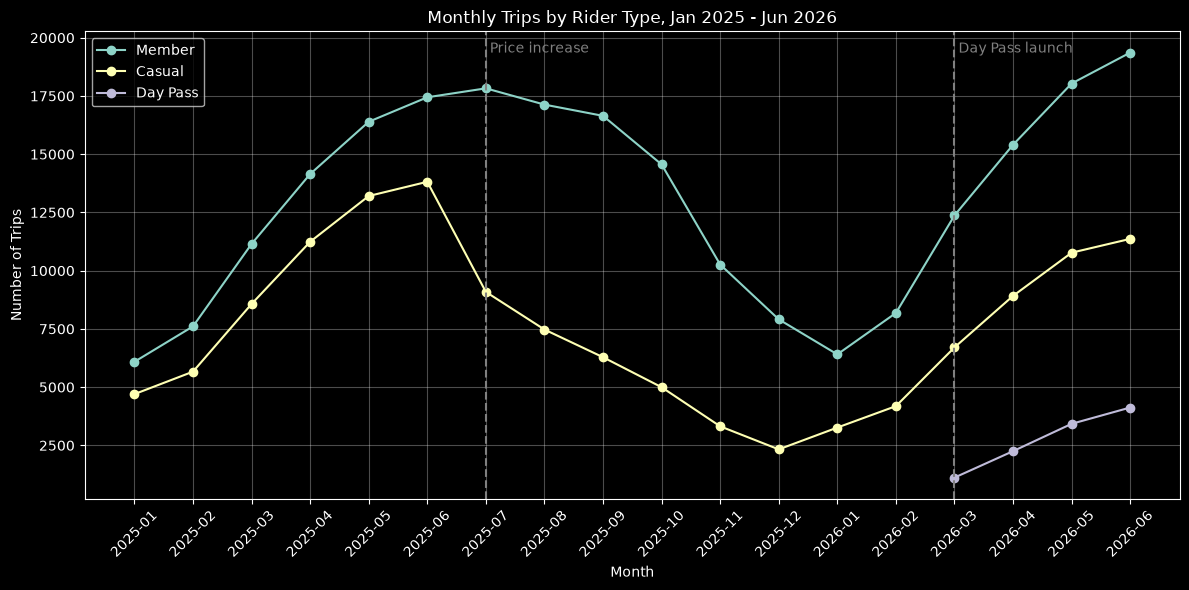

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_trips.index, monthly_trips["member"], marker="o", label="Member")
ax.plot(monthly_trips.index, monthly_trips["casual"], marker="o", label="Casual")

# Day pass only exists from March 2026, so only plot those months
day_pass_months = monthly_trips[monthly_trips["day pass"] > 0]
ax.plot(day_pass_months.index, day_pass_months["day pass"], marker="o", label="Day Pass")

# mark the price increase and the day pass launch
ax.axvline("2025-07", color="gray", linestyle="--")
ax.axvline("2026-03", color="gray", linestyle="--")
ax.text("2025-07", monthly_trips["member"].max(), " Price increase", color="gray")
ax.text("2026-03", monthly_trips["member"].max(), " Day Pass launch", color="gray")

ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
ax.set_title("Monthly Trips by Rider Type, Jan 2025 - Jun 2026")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/monthly_trips_by_rider_type_2025_2026.png")
plt.show()

In [29]:
# How big was the drop after the price increase? (June 2025 vs July 2025)
for rider in ["member", "casual"]:
    june = monthly_trips.loc["2025-06", rider]
    july = monthly_trips.loc["2025-07", rider]
    percent_change = (july - june) / june * 100
    print(f"{rider}: June 2025 = {june}, July 2025 = {july}, change = {percent_change:+.2f}%")

member: June 2025 = 17444, July 2025 = 17828, change = +2.20%
casual: June 2025 = 13816, July 2025 = 9088, change = -34.22%


## Did non-membership recover?

Look at casual + day pass vs member

Look at casual vs member

Look at day pass vs member

In [30]:
# Compare member trips across the available calendar-year data.
# Note: 2026 contains January–June only, so this is not a full-year comparison.

member_counts_2025_full_year = (
    merged_2025["rider_type"] == "member"
).sum()

member_counts_2026_available = (
    merged_2026["rider_type"] == "member"
).sum()

change = member_counts_2026_available - member_counts_2025_full_year
percent_change = change / member_counts_2025_full_year * 100

print(f"Member trips,2025: {member_counts_2025_full_year:,}")
print(f"Member trips, January–June 2026: {member_counts_2026_available:,}")
print(f"Difference: {change}")
print(f"Percentage difference: {percent_change:+.2f}%")

Member trips,2025: 157,165
Member trips, January–June 2026: 79,764
Difference: -77401
Percentage difference: -49.25%


**2026 is only a half-year, so these totals are not directly comparable.**

In [31]:
# Compare the same January–June period because 2026 data covers only H1.
merged_2025_jan_jun = merged_2025[merged_2025["month"].between(1, 6)]

member_counts_2025 = (merged_2025_jan_jun["rider_type"] == "member").sum()
member_counts_2026 = (merged_2026["rider_type"] == "member").sum()

print(f"Member trips, Jan–Jun 2025: {member_counts_2025}")
print(f"Member trips, Jan–Jun 2026: {member_counts_2026}")

change = member_counts_2026 - member_counts_2025
percent_change = change / member_counts_2025 * 100

print(f"Difference: {change}")
print(f"User increase for members: {percent_change:+.2f}%")

Member trips, Jan–Jun 2025: 72826
Member trips, Jan–Jun 2026: 79764
Difference: 6938
User increase for members: +9.53%


In [32]:
# TODO split non-member trips from member trips for further analysis
non_member_trips_2025 = merged_2025_jan_jun[merged_2025_jan_jun["rider_type"] == "casual"]
non_member_trips_2026 = merged_2026[merged_2026["rider_type"].isin(["casual", "day pass"])]

print(f"Non-member trips, Jan–Jun 2025: {len(non_member_trips_2025)}")
print(f"Non-member trips, Jan–Jun 2026: {len(non_member_trips_2026)}")

change_non_member = len(non_member_trips_2026) - len(non_member_trips_2025)
percent_change_non_member = change_non_member / len(non_member_trips_2025) * 100

print(f"Difference for non-members: {change_non_member}")
print(f"User difference for non-members: {percent_change_non_member:+.2f}%")

Non-member trips, Jan–Jun 2025: 57193
Non-member trips, Jan–Jun 2026: 56124
Difference for non-members: -1069
User difference for non-members: -1.87%


In [33]:
#TODO compare day pass trips and casual trips for non-members
day_pass_trips_2026 = merged_2026[merged_2026["rider_type"] == "day pass"]
casual_trips_2026 = merged_2026[merged_2026["rider_type"] == "casual"]

print(f"Day pass trips, Jan–Jun 2026: {len(day_pass_trips_2026)}")
print(f"Casual trips, Jan–Jun 2026: {len(casual_trips_2026)}")

# were there the same casual trips in 2025 (Jan-Jun) as in 2026
casual_trips_2025 = non_member_trips_2025[non_member_trips_2025["rider_type"] == "casual"]
print(f"Casual trips, Jan–Jun 2025: {len(casual_trips_2025)}")

# compare casual trips for non-members between 2025 and 2026
change_casual = len(casual_trips_2026) - len(casual_trips_2025)
percent_change_casual = change_casual / len(casual_trips_2025) * 100
print(f"Difference for casual trips: {change_casual}")
print(f"User difference for casual trips: {percent_change_casual:+.2f}%")

Day pass trips, Jan–Jun 2026: 10917
Casual trips, Jan–Jun 2026: 45207
Casual trips, Jan–Jun 2025: 57193
Difference for casual trips: -11986
User difference for casual trips: -20.96%


In [34]:
# what percentage of non-member riders in 2026 opt for a day pass over being a casual rider?
non_members_day_pass_percentage = len(day_pass_trips_2026) / len(non_member_trips_2026) * 100
print(f"Percentage of non-member riders in 2026 opting for a day pass: {non_members_day_pass_percentage:.2f}%")
non_members_casual_percentage = len(casual_trips_2026) / len(non_member_trips_2026) * 100
print(f"Percentage of non-member riders in 2026 opting for a casual ride: {non_members_casual_percentage:.2f}%")    

Percentage of non-member riders in 2026 opting for a day pass: 19.45%
Percentage of non-member riders in 2026 opting for a casual ride: 80.55%


In [35]:
# what is the difference between non-member usage in May-2025 vs May-2026?
may_2025_non_member = non_member_trips_2025[non_member_trips_2025["month"] == 5].shape[0]
may_2026_non_member = non_member_trips_2026[non_member_trips_2026["month"] == 5].shape[0]
may_non_member_difference = may_2026_non_member - may_2025_non_member

print(f"May 2025 Non-Member Trips:\n {may_2025_non_member}")
print(f"May 2026 Non-Member Trips:\n {may_2026_non_member}")
print(f"Difference in Non-Member Trips (May 2026 - May 2025):\n {may_non_member_difference}") 

# how much is usage up for non-members in May 2026 compared to May 2025
may_non_member_usage_increase = (may_non_member_difference / may_2025_non_member) * 100
print(f"Percentage Increase in Non-Member Trips (May 2026 vs May 2025):\n {may_non_member_usage_increase:.2f}%")

# how many of the non-member trips were day pass trips in May 2026
day_pass_trips_may_2026 = day_pass_trips_2026[day_pass_trips_2026["month"] == 5].shape[0]
print(f"Day Pass Trips (Non-Member) in May 2026:\n {day_pass_trips_may_2026}")

# what percentage of non-member trips in May 2026 were day pass trips
day_pass_percentage_may_2026 = (day_pass_trips_may_2026 / may_2026_non_member) * 100
print(f"Percentage of Non-Member Trips that were Day Pass Trips (May 2026):\n {day_pass_percentage_may_2026:.2f}%")

May 2025 Non-Member Trips:
 13205
May 2026 Non-Member Trips:
 14197
Difference in Non-Member Trips (May 2026 - May 2025):
 992
Percentage Increase in Non-Member Trips (May 2026 vs May 2025):
 7.51%
Day Pass Trips (Non-Member) in May 2026:
 3425
Percentage of Non-Member Trips that were Day Pass Trips (May 2026):
 24.12%


## Analysis: Did non-membership recover?

Yes, but are not seeing a meaningful increase of casual ridership from 2025 to 2026. In the following analysis, non-members include day pass riders and casual riders for 2026.

Non-member trips, Jan–Jun 2025: 57193
Non-member trips, Jan–Jun 2026: 56124
Difference for non-members: -1069
User difference for non-members: -1.87%

Note, I am only comparing across Jan-Jun because that is all that is available for 2026, and we also want to see the usage before the price increase went into affect in July 2025. 

Usage for non-members is down 1.87% from 2025 pre-price increase in 2026. 

However, it does seem like 19.45% of non-member users in 2026 are opting for day passes over just using a one-trip casual ride.

In the figure "Non-member Ridership: 2025 vs 2026 (Jan-Jun)" we can see that ridership for non-members is on an increasing trend in comparison to 2025. While, currently combined non-membership rides for 2026 is slightly below 2026, it is greater in months following March of 2026 than it was in Months following March in 2025. The day pass was implemented in March and may be responsible for this positive trend.

To elaborate, if we just look at the May of 2026 (most recent logged month) we can see that casual rider ship is up 7.51% from May of 2025, which is an increase of 992 trips. Approximately a quarter of these trips in May were day pass users.

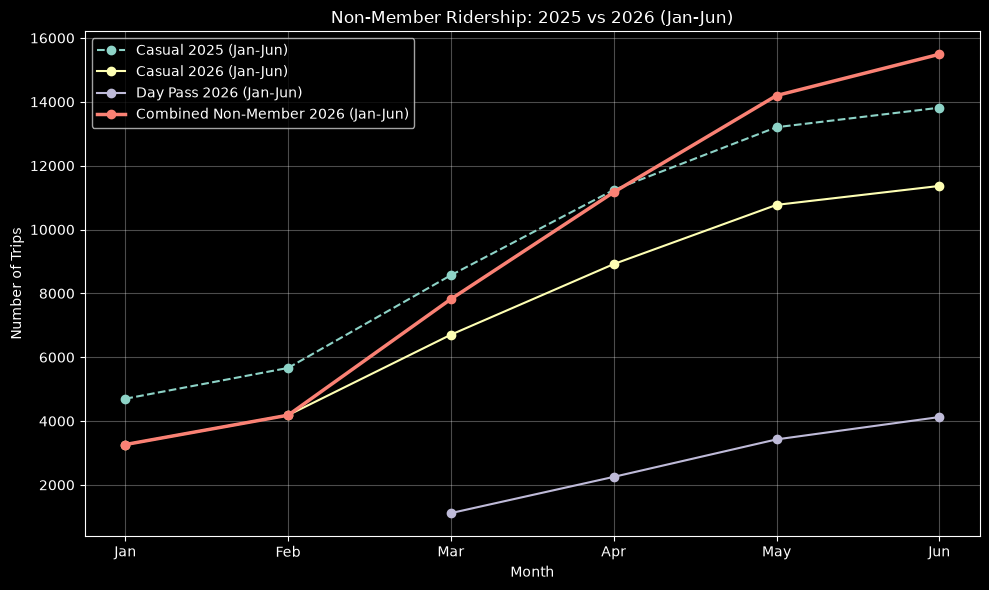

In [36]:
# Build monthly counts for non-member ridership comparison (Jan-Jun 2025 vs Jan-Jun 2026)
months = range(1, 7)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]

casual_2025_monthly = non_member_trips_2025.groupby("month").size().reindex(months)
casual_2026_monthly = casual_trips_2026.groupby("month").size().reindex(months)
day_pass_2026_monthly = day_pass_trips_2026.groupby("month").size().reindex(months)
non_member_2026_monthly = non_member_trips_2026.groupby("month").size().reindex(months)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(month_labels, casual_2025_monthly, marker='o', label="Casual 2025 (Jan-Jun)", linestyle='--')
ax.plot(month_labels, casual_2026_monthly, marker='o', label="Casual 2026 (Jan-Jun)")
ax.plot(month_labels, day_pass_2026_monthly, marker='o', label="Day Pass 2026 (Jan-Jun)")
ax.plot(month_labels, non_member_2026_monthly, marker='o', label="Combined Non-Member 2026 (Jan-Jun)", linewidth=2.5)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
ax.set_title("Non-Member Ridership: 2025 vs 2026 (Jan-Jun)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("charts/non_member_ridership_jan_jun_2025_vs_2026.png")
plt.show()

# save to folder -- charts

In [37]:
# Month-by-month comparison table (Jan-Jun 2025 vs Jan-Jun 2026)
recovery_table = pd.DataFrame({
    "casual_2025": casual_2025_monthly,
    "casual_2026": casual_2026_monthly,
    "day_pass_2026": day_pass_2026_monthly.fillna(0),
    "non_member_2026": non_member_2026_monthly,
})

recovery_table["casual_change_%"] = (recovery_table["casual_2026"] - recovery_table["casual_2025"]) / recovery_table["casual_2025"] * 100
recovery_table["non_member_change_%"] = (recovery_table["non_member_2026"] - recovery_table["casual_2025"]) / recovery_table["casual_2025"] * 100
recovery_table.index = month_labels

display(recovery_table.round(1))

,casual_2025,casual_2026,day_pass_2026,non_member_2026,casual_change_%,non_member_change_%
Jan,4699,3264,0.0,3264,-30.5,-30.5
Feb,5664,4184,0.0,4184,-26.1,-26.1
Mar,8569,6705,1116.0,7821,-21.8,-8.7
Apr,11240,8917,2251.0,11168,-20.7,-0.6
May,13205,10772,3425.0,14197,-18.4,7.5
Jun,13816,11365,4125.0,15490,-17.7,12.1


**Reading the table:** `casual_change_%` compares casual riders only. `non_member_change_%` counts casual + day pass riders in 2026 against casual riders in 2025. The answer to "did non-members recover?" depends on which one you use, so both are shown.

## Did the S06 and S08 dock expansion relieve pressure?

In [38]:
# remember to use this dataframe for 2025 "merged_2025_jan_jun"

S06_2025 = merged_2025_jan_jun[merged_2025_jan_jun["station_id"] == "S06"]
S08_2025 = merged_2025_jan_jun[merged_2025_jan_jun["station_id"] == "S08"]
S06_SO8_2025 = pd.concat([S06_2025, S08_2025])

S06_2026 = merged_2026[merged_2026["station_id"] == "S06"]
S08_2026 = merged_2026[merged_2026["station_id"] == "S08"]
S06_SO8_2026 = pd.concat([S06_2026, S08_2026])
All_S06_S08 = pd.concat([S06_SO8_2025, S06_SO8_2026])

# add 2025 and 2026 year columns for later grouping
S06_SO8_2025["year"] = 2025
S06_SO8_2026["year"] = 2026
All_S06_S08["year"] = All_S06_S08["start_time"].dt.year 

#display(All_S06_S08.sample(5))

S24_2025 = merged_2025_jan_jun[merged_2025_jan_jun["station_id"] == "S24"]
S23_2025 = merged_2025_jan_jun[merged_2025_jan_jun["station_id"] == "S23"]
S24_2026 = merged_2026[merged_2026["station_id"] == "S24"]
S23_2026 = merged_2026[merged_2026["station_id"] == "S23"]
S23_S24_2025 = pd.concat([S23_2025, S24_2025])
S23_S24_2026 = pd.concat([S23_2026, S24_2026])
All_S23_S24 = pd.concat([S23_S24_2025, S23_S24_2026])

# add 2025 and 2026 year columns for later grouping
S23_S24_2025["year"] = 2025
S23_S24_2026["year"] = 2026
All_S23_S24["year"] = All_S23_S24["start_time"].dt.year 

In [39]:
# trips per dock for every station, Jan-Jun 2025
per_station_2025 = (merged_2025_jan_jun.groupby(["station_id", "docks"],dropna=False).size().reset_index(name="trips"))
per_station_2025["trips_per_dock"] = (per_station_2025["trips"] / per_station_2025["docks"])
per_station_2025 = per_station_2025.sort_values("trips_per_dock", ascending=True)

print("Five least-pressured stations, 2025:")
display(per_station_2025.head())
print("Five most-pressured stations, 2025:")
display(per_station_2025.tail())

Five least-pressured stations, 2025:


,station_id,docks,trips,trips_per_dock
22,S23,12,1075,89.583333
23,S24,10,981,98.100000
20,S21,10,1467,146.700000
19,S20,10,1837,183.700000
14,S15,10,1989,198.900000


Five most-pressured stations, 2025:


,station_id,docks,trips,trips_per_dock
7,S08,24,13084,545.166667
5,S06,24,13535,563.958333
0,S01,20,11861,593.050000
10,S11,16,9931,620.687500
6,S07,12,7456,621.333333


In [40]:
# trips per dock for every station, Jan-Jun 2026
per_station_2026 = (merged_2026.groupby(["station_id", "docks"],dropna=False).size().reset_index(name="trips"))
per_station_2026["trips_per_dock"] = (per_station_2026["trips"] / per_station_2026["docks"])
per_station_2026 = per_station_2026.sort_values("trips_per_dock", ascending=True)

print("Five least-pressured stations, 2026:")
display(per_station_2026.head())
print("Five most-pressured stations, 2026:")
display(per_station_2026.tail())

Five least-pressured stations, 2026:


,station_id,docks,trips,trips_per_dock
23,S24,10,982,98.200000
20,S21,10,1497,149.700000
22,S23,12,2225,185.416667
19,S20,10,1959,195.900000
14,S15,10,2045,204.500000


Five most-pressured stations, 2026:


,station_id,docks,trips,trips_per_dock
3,S04,16,7722,482.625000
1,S02,16,8943,558.937500
10,S11,16,8971,560.687500
6,S07,12,6863,571.916667
0,S01,20,12380,619.000000


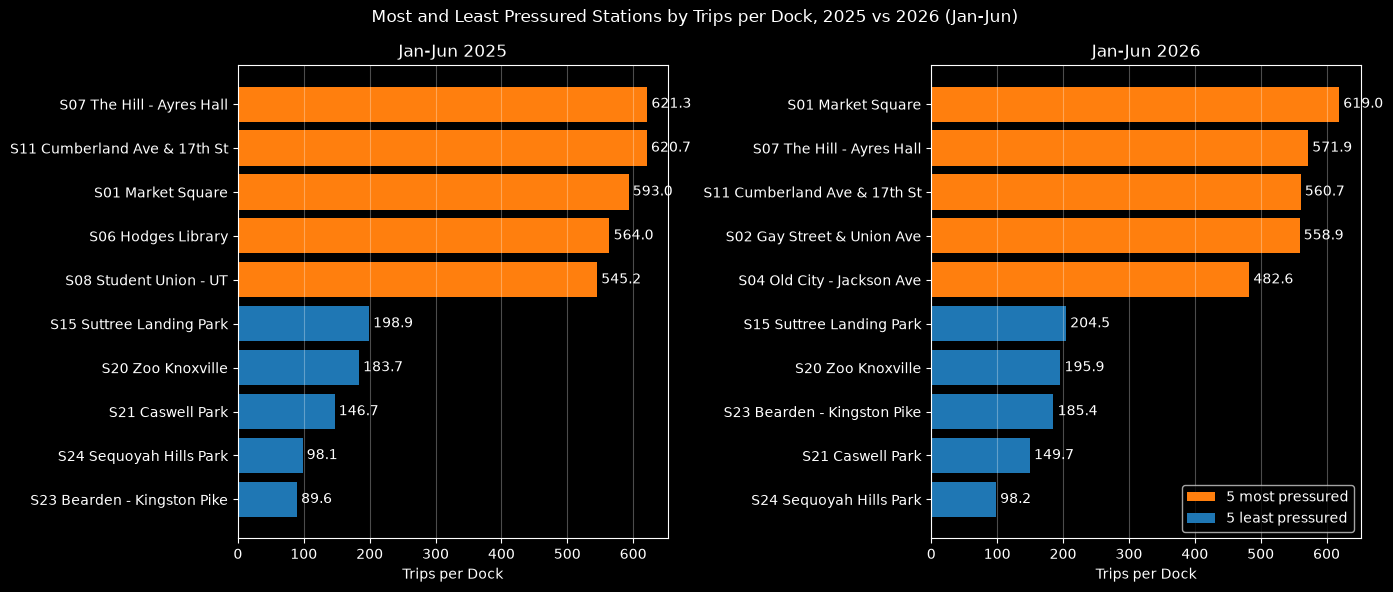

In [41]:
# add station names so the chart labels are easy to read
per_station_2025 = per_station_2025.merge(stations_2025_raw[["station_id", "station_name"]], on="station_id")
per_station_2026 = per_station_2026.merge(stations_2026_raw[["station_id", "station_name"]], on="station_id")
per_station_2025["label"] = per_station_2025["station_id"] + " " + per_station_2025["station_name"]
per_station_2026["label"] = per_station_2026["station_id"] + " " + per_station_2026["station_name"]

# 5 most and 5 least pressured stations for each year (highest first)
top_5_2025 = per_station_2025.sort_values("trips_per_dock", ascending=False).head(5)
bottom_5_2025 = per_station_2025.sort_values("trips_per_dock", ascending=False).tail(5)
top_5_2026 = per_station_2026.sort_values("trips_per_dock", ascending=False).head(5)
bottom_5_2026 = per_station_2026.sort_values("trips_per_dock", ascending=False).tail(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

for ax, top_5, bottom_5, year in [(axes[0], top_5_2025, bottom_5_2025, "2025"),
                                  (axes[1], top_5_2026, bottom_5_2026, "2026")]:
    ax.barh(top_5["label"], top_5["trips_per_dock"], color="tab:orange", label="5 most pressured")
    ax.barh(bottom_5["label"], bottom_5["trips_per_dock"], color="tab:blue", label="5 least pressured")
    ax.invert_yaxis()
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f", padding=3)
    ax.set_xlabel("Trips per Dock")
    ax.set_title(f"Jan-Jun {year}")
    ax.grid(axis="x", alpha=0.3)

axes[1].legend(loc="lower right")
fig.suptitle("Most and Least Pressured Stations by Trips per Dock, 2025 vs 2026 (Jan-Jun)")

plt.tight_layout()
plt.savefig("charts/top_bottom_5_stations_2025_vs_2026_Jan-Jun.png")
plt.show()

Note: S25 opened March 1, 2026, so its trips per dock cover 4 months instead of 6.

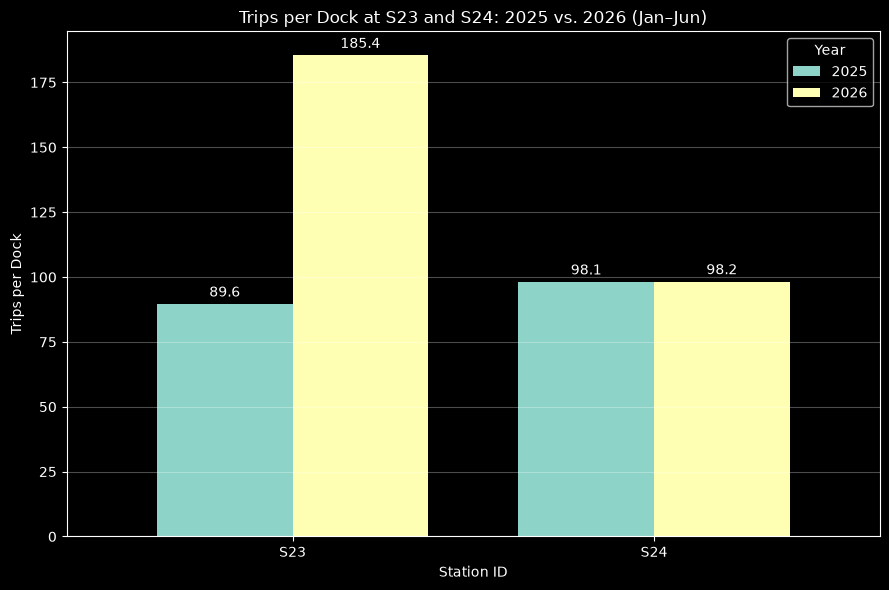

In [42]:
# pressure at S23 and S24 (Jan–Jun) 2025 vs 2026 

pressure_by_year_S23_S24 = (All_S23_S24.groupby(["station_id", "year", "docks"]).size().reset_index(name="trips"))

pressure_by_year_S23_S24["trips_per_dock"] = (pressure_by_year_S23_S24["trips"] / pressure_by_year_S23_S24["docks"])

pressure_plot_S23_S24 = pressure_by_year_S23_S24.pivot(index="station_id", columns="year", values="trips_per_dock").reindex(["S23", "S24"])

ax = pressure_plot_S23_S24.plot(
    kind="bar",
    figsize=(9, 6),
    width=0.75
)

ax.set_xlabel("Station ID")
ax.set_ylabel("Trips per Dock")
ax.set_title("Trips per Dock at S23 and S24: 2025 vs. 2026 (Jan–Jun)")
ax.legend(title="Year")
ax.grid(axis="y", alpha=0.3)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("./charts/pressure_comparison_S23_S24_2025_vs_2026_Jan-Jun.png")
plt.show()

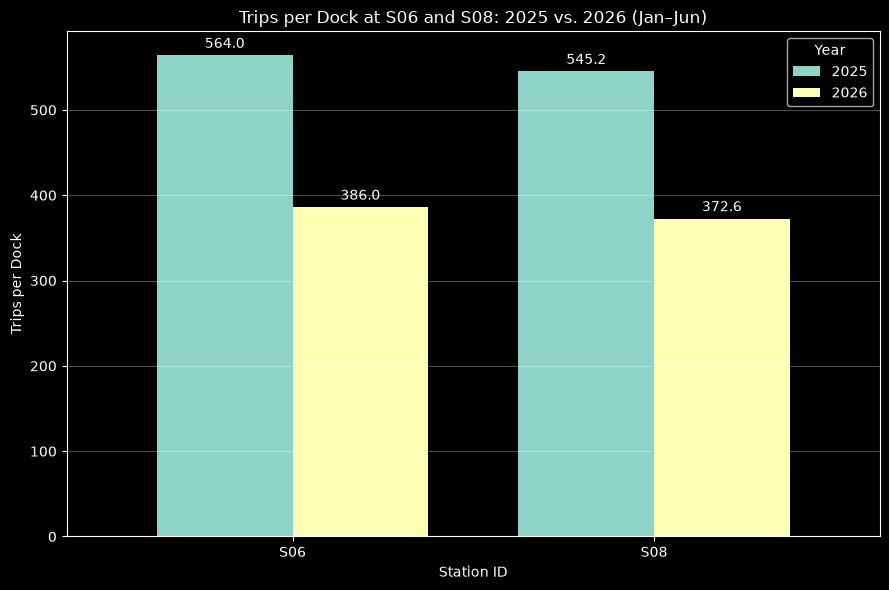

In [43]:
# compare pressure at S06 and S08 from 2025 and 2026 (Jan-Jun) using bar chart

pressure_by_year = (All_S06_S08.groupby(["station_id", "year", "docks"]).size().reset_index(name="trips"))

pressure_by_year["trips_per_dock"] = (pressure_by_year["trips"] / pressure_by_year["docks"])

pressure_plot = pressure_by_year.pivot(index="station_id",columns="year", values="trips_per_dock").reindex(["S06", "S08"])

ax = pressure_plot.plot(
    kind="bar",
    figsize=(9, 6),
    width=0.75
)

ax.set_xlabel("Station ID")
ax.set_ylabel("Trips per Dock")
ax.set_title("Trips per Dock at S06 and S08: 2025 vs. 2026 (Jan–Jun)")
ax.legend(title="Year")
ax.grid(axis="y", alpha=0.3)

# Add value labels to each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
# AI usage ^ copilot suggest and I liked that it add the values.

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("./charts/pressure_comparison_S06_S08_2025_vs_2026_Jan-Jun.png")
plt.show()

In [44]:
# percentage difference in trips per dock between 2025 and 2026 (Jan–Jun) for S06 and S08
pressure_diff = ((pressure_plot[2026] - pressure_plot[2025]) / pressure_plot[2025]) * 100
display(pressure_diff)

# percentage difference in trips per dock S23 and S24 (Jan–Jun) 2025 vs 2026
pressure_diff_S23_S24 = ((pressure_plot_S23_S24[2026] - pressure_plot_S23_S24[2025]) / pressure_plot_S23_S24[2025]) * 100
display(pressure_diff_S23_S24)

station_id
S06   -31.555227
S08   -31.660807
dtype: float64

station_id
S23    106.976744
S24      0.101937
dtype: float64

## Analysis: Did pressure change for stations S06, S08, S23, S24? How is the new station S25 performing?

Dock expansion for S06 and S08 did relieve pressure at those stations. With approximately ~30% less pressure at those docks in the 2026 data than in 2025 (Jan-Jun).

Docks S23 is experiencing more pressure in 2026 than in 2025, with S23 having over a 100% difference in pressure. There is no change in pressure for dock S24 in the same period.

The new station S25 is performing well being ranked in the top 10 stations, being the 8th most pressured station.

## Who are the day pass riders?

Are they riding on weekends or during the week? 
How long are the trips of day pass riders in 2026? 
How long does the trips of day pass riders compare to casual riders in 2025?

In [45]:
# remember to use "merged_2025_jan_jun" and "merged_2026"

merged_2025_causal = merged_2025_jan_jun[merged_2025_jan_jun["rider_type"] == "casual"]
merged_2026_day_pass = merged_2026[merged_2026["rider_type"] == "day pass"]


# what days of the week have the most casual riders in 2025 (Jan–Jun) group by "day_name"
casual_days_2025 = merged_2025_causal.groupby("day_name").size().reset_index(name="trips")
display(casual_days_2025)
# what days of the week have the most day pass riders in 2026 group by "day_name"
day_pass_days_2026 = merged_2026_day_pass.groupby("day_name").size().reset_index(name="trips")
display(day_pass_days_2026)

# compare the most popular days for casual riders in 2025 (Jan–Jun) vs day pass riders in 2026
comparison = casual_days_2025.merge(day_pass_days_2026, on="day_name", suffixes=("_casual_2025", "_day_pass_2026"))
display(comparison)

,day_name,trips
0,Friday,8168
1,Monday,8231
2,Saturday,8309
3,Sunday,8288
4,Thursday,8097
5,Tuesday,7924
6,Wednesday,8176


,day_name,trips
0,Friday,841
1,Monday,851
2,Saturday,3308
3,Sunday,3382
4,Thursday,805
5,Tuesday,902
6,Wednesday,828


,day_name,trips_casual_2025,trips_day_pass_2026
0,Friday,8168,841
1,Monday,8231,851
2,Saturday,8309,3308
3,Sunday,8288,3382
4,Thursday,8097,805
5,Tuesday,7924,902
6,Wednesday,8176,828


Day trip passes see a rise in purchase during the weekend: Sat and Sun.

In [46]:
# how long are trips for casual riders in 2025 and day pass riders in 2026?
# (mean and median of all trips)
casual_2026_trips = merged_2026[merged_2026["rider_type"] == "casual"]
member_2026_trips = merged_2026[merged_2026["rider_type"] == "member"]

print(f"Day pass 2026: average {merged_2026_day_pass['duration_min'].mean():.1f} min, median {merged_2026_day_pass['duration_min'].median():.1f} min")
print(f"Casual 2025:   average {merged_2025_causal['duration_min'].mean():.1f} min, median {merged_2025_causal['duration_min'].median():.1f} min")
print(f"Casual 2026:   average {casual_2026_trips['duration_min'].mean():.1f} min, median {casual_2026_trips['duration_min'].median():.1f} min")
print(f"Member 2026:   average {member_2026_trips['duration_min'].mean():.1f} min, median {member_2026_trips['duration_min'].median():.1f} min")

# how long are rides on weekends (sat and sun)?
weekend_day_pass_2026 = merged_2026_day_pass[merged_2026_day_pass["day_name"].isin(["Saturday", "Sunday"])]
weekend_casual_2025 = merged_2025_causal[merged_2025_causal["day_name"].isin(["Saturday", "Sunday"])]
print(f"\nAverage weekend day pass duration in 2026: {weekend_day_pass_2026['duration_min'].mean():.1f} minutes")
print(f"Average weekend casual duration in 2025: {weekend_casual_2025['duration_min'].mean():.1f} minutes")

# what share of trips happen on the weekend?
print(f"\nWeekend share of trips, day pass 2026: {merged_2026_day_pass['is_weekend'].mean() * 100:.1f}%")
print(f"Weekend share of trips, casual 2025:   {merged_2025_causal['is_weekend'].mean() * 100:.1f}%")
print(f"Weekend share of trips, member 2026:   {member_2026_trips['is_weekend'].mean() * 100:.1f}%")

Day pass 2026: average 24.1 min, median 20.6 min
Casual 2025:   average 22.9 min, median 19.0 min
Casual 2026:   average 22.9 min, median 19.0 min
Member 2026:   average 13.6 min, median 11.7 min

Average weekend day pass duration in 2026: 24.1 minutes
Average weekend casual duration in 2025: 23.0 minutes

Weekend share of trips, day pass 2026: 61.3%
Weekend share of trips, casual 2025:   29.0%
Weekend share of trips, member 2026:   28.7%


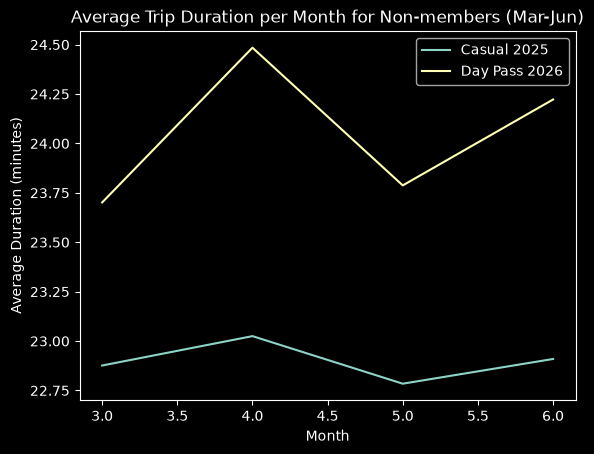

In [47]:
# plot the average trip duration for casual riders in 2025 and day trip riders in 2026 per month (Mar-Jun)
casual_duration_by_month_2025 = merged_2025_causal[merged_2025_causal["month"].isin([3, 4, 5, 6])].groupby("month")["duration_min"].mean().reset_index(name="average_duration")
day_pass_duration_by_month_2026 = merged_2026_day_pass[merged_2026_day_pass["month"].isin([3, 4, 5, 6])].groupby("month")["duration_min"].mean().reset_index(name="average_duration")

plt.plot(casual_duration_by_month_2025["month"], casual_duration_by_month_2025["average_duration"], label="Casual 2025")
plt.plot(day_pass_duration_by_month_2026["month"], day_pass_duration_by_month_2026["average_duration"], label="Day Pass 2026")
plt.xlabel("Month")
plt.ylabel("Average Duration (minutes)")
plt.title("Average Trip Duration per Month for Non-members (Mar-Jun)")
plt.legend()
plt.savefig("./charts/average_trip_duration_non_members_mar_jun.png")
plt.show()

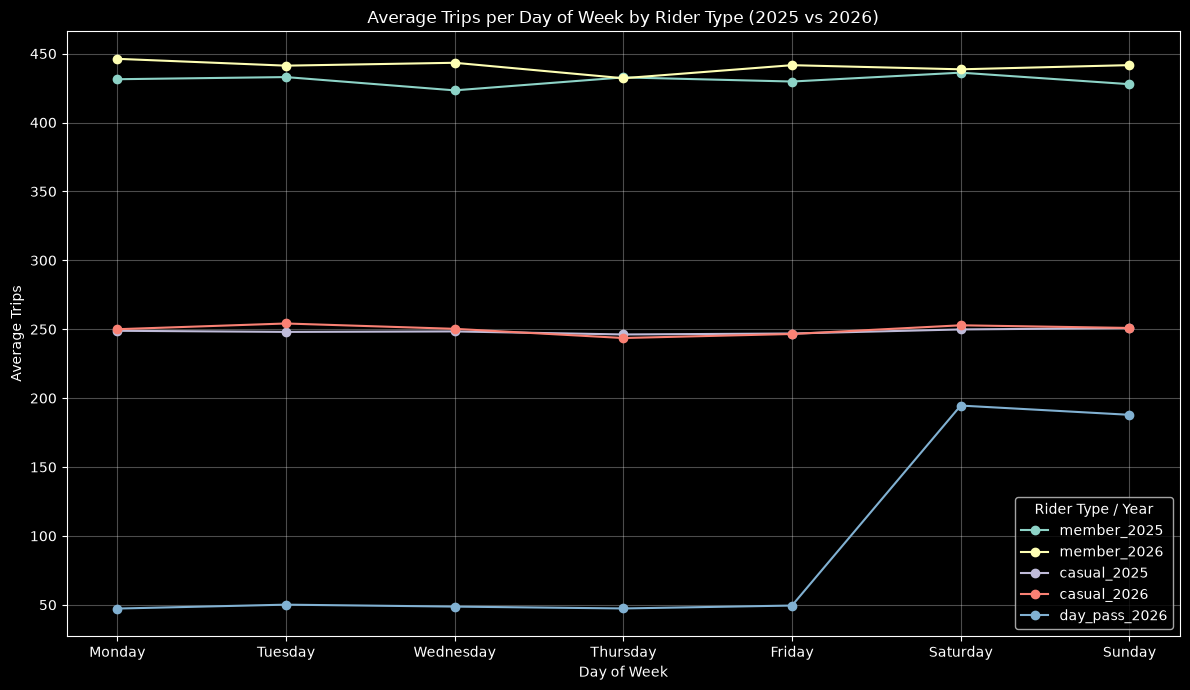

In [48]:
# Calculate average trips per day of week by rider type, for 2025 and 2026

def avg_trips_by_day_rider(df, year_label):
    daily = (
        df.assign(date=df["start_time"].dt.date)
        .groupby(["date", "day_name", "rider_type"])
        .size()
        .reset_index(name="trips")
    )
    avg = (
        daily.groupby(["day_name", "rider_type"])["trips"]
        .mean()
        .reset_index(name="average_trips")
    )
    avg["year"] = year_label
    return avg

avg_2025 = avg_trips_by_day_rider(merged_2025, 2025)
avg_2026 = avg_trips_by_day_rider(merged_2026, 2026)

avg_combined = pd.concat([avg_2025, avg_2026], ignore_index=True)

# Build a single label combining rider type and year so members/casual/day pass
# for each year are all distinct series (members_2025, members_2026, casual_2025,
# casual_2026, day_pass_2026)
avg_combined["series"] = (
    avg_combined["rider_type"].str.replace(" ", "_") + "_" + avg_combined["year"].astype(str)
)

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_combined["day_name"] = pd.Categorical(avg_combined["day_name"], categories=day_order, ordered=True)
avg_combined = avg_combined.sort_values(["series", "day_name"])

# Expected series: members_2025, members_2026, casual_2025, casual_2026, day_pass_2026
series_order = ["member_2025", "member_2026", "casual_2025", "casual_2026", "day_pass_2026"]

fig, ax = plt.subplots(figsize=(12, 7))

for series_name in series_order:
    subset = avg_combined[avg_combined["series"] == series_name]
    if subset.empty:
        continue
    subset = subset.sort_values("day_name")
    ax.plot(subset["day_name"], subset["average_trips"], marker="o", label=series_name)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Trips")
ax.set_title("Average Trips per Day of Week by Rider Type (2025 vs 2026)")
ax.legend(title="Rider Type / Year")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./charts/average_trips_per_day_rider_type_2025_vs_2026.png")
plt.show()

## Analysis: Who are the day pass riders?

The day pass riders are mostly riding on the weekends. As we can see in the "Average Trips per Day of Week by Rider Type (2025 vs 2026)?" plot day pass riders are mostly riding on Sat and Sun. The trips for casual and member riders stays consistent during from 2025 to 2026 for all weekdays.

## Memo:
The data for Ride Knox 2026 shows that casual riders and non-member riders are returning. In the figure "Non-member Ridership: 2025 vs 2026 (Jan-Jun)" we can see that ridership for non-members is on an increasing trend in comparison to 2025. While, currently combined non-membership rides for 2026 is slightly below 2026, it is greater in months following March of 2026 than it was in Months following March in 2025. The day pass was implemented in March and may be responsible for this positive trend.

To elaborate, if we just look at the May of 2026 (most recent logged month) we can see that casual rider ship is up 7.51% from May of 2025, which is an increase of 992 trips. Approximately a quarter of these trips in May were day pass users.

Additionally, we can see the behavior of day pass users by looking at trips taken on specific days of the week. Day pass use increases on Sat and Sun. The usage for other rider types is consistent to pre-price increase in 2025. The trend can be seen in "Average Trips per Day of Week by Rider Type (2025 vs 2026)".

For the dock expansion of S06 and S08, we can see that pressure decreased in this area by ~30%, the figure "Trips per Dock at S06 and S08: 2025 vs. 2026 (Jan–Jun)" shows the difference in pressure after the expansion. To add, the new dock S25 is performing relatively well, ranking in the 8th most pressured dock.

Overall, day passes have seemed to bring back some users to Ride Knox and may be responsible for additional weekend usage. For the future, Ride Knox may consider specials or different pricing for University Games or special events. 

For more information see project_outline_exp.ipynb and "Analysis" comments for elaboration on specific findings.

## Limitations

1. Only six months of 2026 data; the fall, when the 2025 decline was largest, is not observed yet.
2. Spring 2026 weather, novelty, and marketing are not controlled, so "the day pass caused the recovery" is an interpretation, not a proven fact.
3. About 800 January–February 2026 trips are missing an `end_time` (app bug).
4. The recovery answer depends on whether day pass riders count as non-members coming back; both versions are reported.

## AI usage:

I used AI to mostly help with some plotting. I especially got confused on plotting average trips per day by rider type. I struggled to parse the data properly and was getting a lot of errors so I asked copilot for assistance. 
Other wise I used my previous notebooks and assignments to help and guide my work.